In [2]:
import os
import sys

current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)

import pandas as pd
from src.models.utils import *
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import pearsonr



In [3]:
merged_df_path = os.path.join(project_root, "data", "processed", "joined_df.csv")
merged_df = pd.read_csv(merged_df_path, encoding='utf-8')

In [ ]:
power_plants = merged_df[['name', 'code']].drop_duplicates()
power_plants = power_plants[power_plants['code'].str.startswith("G")]

In [ ]:
corr_pearsons = []
for _, row in power_plants.iterrows():
    name = row['name']
    code = row['code']
    filtered_df = merged_df[(merged_df['name'] == name) & (merged_df['code'] == code)]
    senstemps = filtered_df['sen_temperature'].values
    gens = filtered_df['generation'].values
    corr_pearson, _ = pearsonr(senstemps, gens)
    print(f"{name}, {code} : {corr_pearson}")
    corr_pearsons.append(corr_pearson)


In [ ]:
plt.hist(corr_pearsons, bins=20)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import xgboost as xgb


In [ ]:
test_errors = []
for _, row in power_plants.iterrows():
    name = row['name']
    code = row['code']
    filtered_df = merged_df[(merged_df['name'] == name) & (merged_df['code'] == code)]
    senstemps = filtered_df['sen_temperature'].values
    gens = filtered_df['generation'].values
    X = senstemps.reshape(-1, 1)
    y = gens

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    # model = xgb.XGBRegressor(objective ='reg:squarederror', n_estimators=100, seed=42)
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_error = compute_relative_rmse(y_pred_train, y_train)
    test_error = compute_relative_rmse(y_pred_test, y_test)

    print(f"{name}, {code}, train error: {train_error:0.2f}, test error: {test_error:0.2f}")
    test_errors.append(test_error)


In [ ]:
plt.hist(test_errors, bins=20)
plt.show()

In [ ]:
from sklearn.cluster import KMeans


In [ ]:
np.random.seed(42)

name = "پرند"
code = "G12"
filtered_df = merged_df[(merged_df['name'] == name) & (merged_df['code'] == code)]
senstemps = filtered_df['sen_temperature'].values
gens = filtered_df['generation'].values
X = senstemps.reshape(-1, 1)
y = gens

kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(np.c_[X, y])

for cluster in np.unique(labels):
    mask = labels == cluster
    reg = LinearRegression().fit(X[mask], y[mask])
    plt.scatter(X[mask], y[mask], label=f'Cluster {cluster}')
    plt.plot(X, reg.predict(X), linewidth=2)

plt.legend()
plt.show()

In [ ]:
from sklearn.linear_model import RANSACRegressor

In [ ]:
np.random.seed(42)

name = "پرند"
code = "G12"
filtered_df = merged_df[(merged_df['name'] == name) & (merged_df['code'] == code)]
senstemps = filtered_df['sen_temperature'].values
gens = filtered_df['generation'].values
X = senstemps.reshape(-1, 1)
y = gens

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_filtered = X_train.copy()
y_filtered = y_train.copy()

lines = []
while True:
    ransac = RANSACRegressor(LinearRegression(), random_state=42)
    ransac.fit(X_filtered, y_filtered)

    inlier_mask = ransac.inlier_mask_
    lines.append((ransac, inlier_mask, X_filtered, y_filtered))

    X_filtered = X_filtered[~inlier_mask]
    y_filtered = y_filtered[~inlier_mask]
    if len(X_filtered) / len(X) < 0.3:
        break
    
y_preds = []
for i, (ransac, inlier_mask, X_part, y_part) in enumerate(lines):
    line_X = np.linspace(0, 50, 1000).reshape(-1, 1)
    line_y = ransac.predict(line_X)
    plt.scatter(X_part[inlier_mask], y_part[inlier_mask], label=f"line {i + 1} inliers", s=1)
    plt.plot(line_X, line_y, linewidth=2, label=f"Ransac model {i + 1}")
    y_preds.append(ransac.predict(X_test))

plt.scatter(X_filtered, y_filtered, label="other points", s=1)
plt.legend()
plt.show()



In [ ]:
y_diffs = np.array([np.abs(y_pred - y_test) for y_pred in y_preds])
min_diff = np.min(y_diffs, axis=0)


In [ ]:
rmse = np.sqrt(np.mean(min_diff**2))
relative_error = rmse / np.mean(y_test) * 100
print(f"{relative_error: 0.2f}")

In [ ]:
def my_func(name, code):
    global filtered_df
    np.random.seed(42)
    filtered_df = merged_df[(merged_df['name'] == name) & (merged_df['code'] == code)]
    senstemps = filtered_df['sen_temperature'].values
    gens = filtered_df['generation'].values
    X = senstemps.reshape(-1, 1)
    y = gens
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_filtered = X_train.copy()
    y_filtered = y_train.copy()
    lines = []
    while True:
        ransac = RANSACRegressor(LinearRegression(), random_state=42)
        ransac.fit(X_filtered, y_filtered)

        inlier_mask = ransac.inlier_mask_
        lines.append((ransac, inlier_mask, X_filtered, y_filtered))

        X_filtered = X_filtered[~inlier_mask]
        y_filtered = y_filtered[~inlier_mask]
        if len(X_filtered) / len(X) < 0.1 or len(X_filtered) < 10:
            break
    y_preds = []
    for i, (ransac, inlier_mask, X_part, y_part) in enumerate(lines):
        line_X = np.linspace(0, 50, 1000).reshape(-1, 1)
        line_y = ransac.predict(line_X)
        plt.scatter(X_part[inlier_mask], y_part[inlier_mask], label=f"line {i + 1} inliers", s=1)
        plt.plot(line_X, line_y, linewidth=2, label=f"Ransac model {i + 1}")
        y_preds.append(ransac.predict(X_test))
    plt.scatter(X_filtered, y_filtered, label="other points", s=1)
    plt.legend()
    plt.show()
    y_diffs = np.array([np.abs(y_pred - y_test) for y_pred in y_preds])
    min_diff = np.min(y_diffs, axis=0)
    rmse = np.sqrt(np.mean(min_diff ** 2))
    relative_error = rmse / np.mean(y_test) * 100
    print(f"{relative_error: 0.2f}")


for _, row in power_plants.iterrows():
    name = row['name']
    code = row['code']
    my_func(name, code)

In [4]:
merged_df.head()

,Unnamed: 0,name,code,date,hour,temperature,sen_temperature,generation,is_good_peak
0,0,پرند,G16,2021-03-23,6,18.328000,15.28,119.975658,0
1,1,پرند,G14,2021-03-23,6,18.328000,15.28,146.924177,0
2,2,پرند,G14,2021-03-23,7,19.627998,13.47,140.142646,0
3,3,پرند,G16,2021-03-23,7,19.627998,13.47,109.792682,0
4,4,پرند,G16,2021-03-23,8,20.627998,13.40,109.542014,0


In [53]:
t1 = merged_df['sen_temperature'].values
t2 = merged_df['temperature'].values


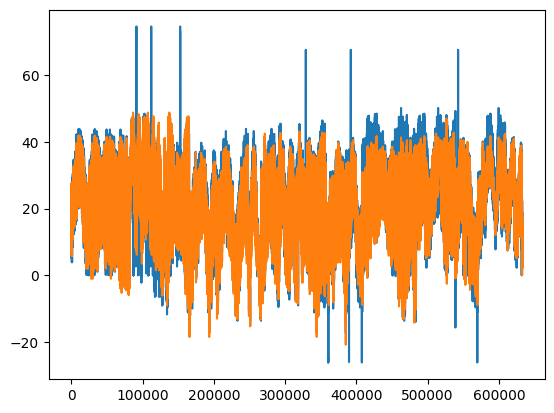

In [54]:
plt.plot(t1)
plt.plot(t2)
plt.show()

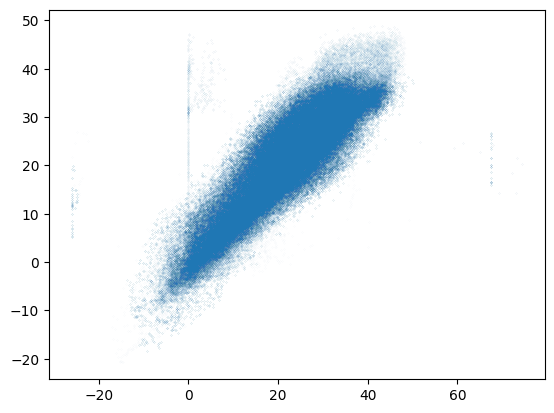

In [55]:
plt.scatter(t1, t2, s=0.01, alpha=0.1)
plt.show()

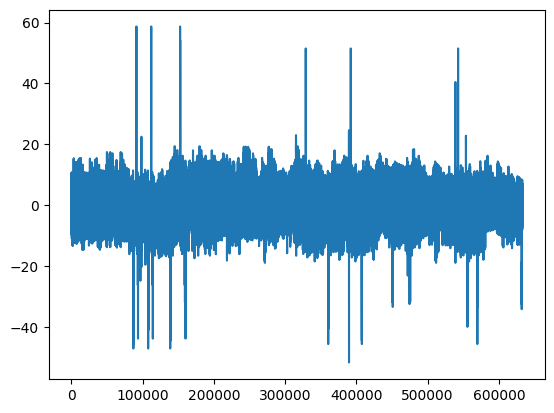

In [56]:
t_diff = t1 - t2
plt.plot(t_diff)
plt.show()

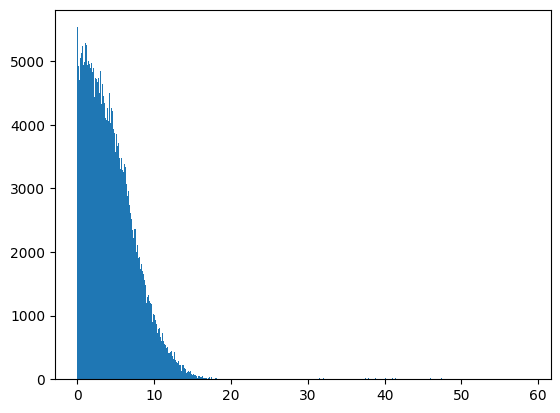

In [57]:
plt.hist(abs(t_diff), bins=1000)
plt.show()

In [58]:
np.mean(t_diff)

np.float64(0.8482512894069172)

In [59]:
merged_df_path2 = os.path.join(project_root, "data", "processed", "joined_df2.csv")
merged_df2 = pd.read_csv(merged_df_path2, encoding='utf-8')

In [60]:
merged_df2

,Unnamed: 0,name,code,date,hour,temperature,env_temperature,generation,is_good_peak
0,0,پرند,G16,2021-03-23,6,18.328000,15.52,119.975658,0
1,1,پرند,G14,2021-03-23,6,18.328000,15.52,146.924177,0
2,2,پرند,G14,2021-03-23,7,19.627998,13.98,140.142646,0
3,3,پرند,G16,2021-03-23,7,19.627998,13.98,109.792682,0
4,4,پرند,G16,2021-03-23,8,20.627998,14.56,109.542014,0
...,...,...,...,...,...,...,...,...,...
725879,739563,حافظ,G11,2024-12-12,15,11.675000,15.39,97.483500,0
725880,739564,حافظ,G11,2024-12-12,16,10.425000,16.03,124.128910,0
725881,739565,حافظ,G11,2024-12-12,17,9.475000,14.99,99.499020,0
725882,739566,حافظ,G11,2024-12-12,18,8.075000,13.40,121.122260,0


In [61]:
t3 = merged_df2['env_temperature'].values
t4 = merged_df2['temperature'].values

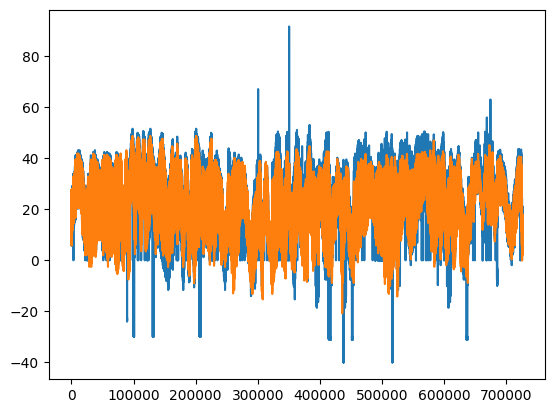

In [62]:
plt.plot(t3)
plt.plot(t4)

plt.show()

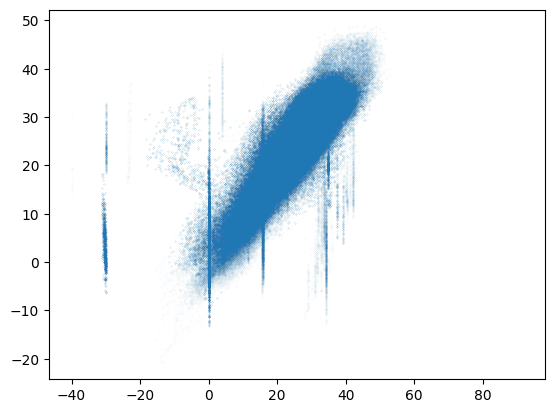

In [63]:
plt.scatter(t3, t4, s=0.01, alpha=0.1)
plt.show()

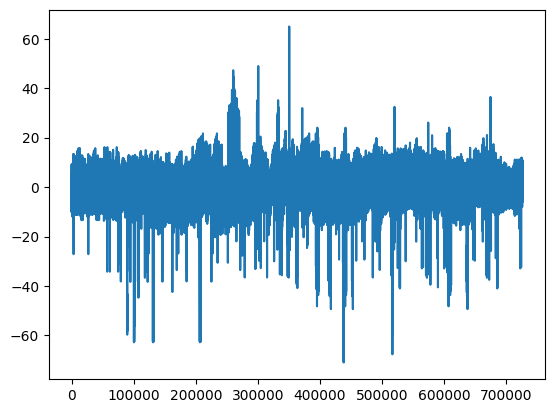

In [64]:
t_diff2 = t3 - t4
plt.plot(t_diff2)
plt.show()


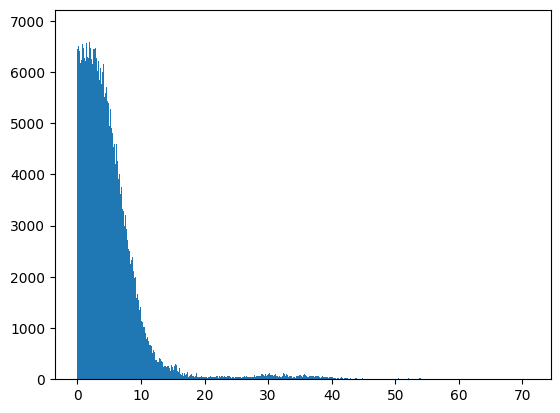

In [65]:
plt.hist(abs(t_diff2), bins=1000)
plt.show()


In [66]:
np.mean(t_diff2)


np.float64(0.8854830887028191)

In [73]:
df_path3 = os.path.join(project_root, "data", "raw", "PlantsTemperature_View_original.csv")
df3 = pd.read_csv(df_path3, encoding='utf-8')
df3["Date"] = df3["Date"].apply(jalali_to_gregorian_fast)
df3["datetime"] = pd.to_datetime(df3["Date"]) + pd.to_timedelta(df3["HourNo"], unit='h')
df3

,PowerPlantCode,PowerPlantName,Date,Name,InsertDateTime,HourNo,Value,Code,datetime
0,104,پرند,2021-03-21,فایل های تولید شده اسکادا,1401/05/05-08:59:01.06,1,11.38,SCADAF,2021-03-21 01:00:00
1,104,پرند,2021-03-21,سنسور دمای نیروگاه,1401/05/05-08:59:01.06,1,12.97,TempSens,2021-03-21 01:00:00
2,104,پرند,2021-03-21,فایل های تولید شده اسکادا,1401/05/05-08:59:01.06,2,10.32,SCADAF,2021-03-21 02:00:00
3,104,پرند,2021-03-21,سنسور دمای نیروگاه,1401/05/05-08:59:01.06,2,9.36,TempSens,2021-03-21 02:00:00
4,104,پرند,2021-03-21,فایل های تولید شده اسکادا,1401/05/05-08:59:01.06,3,11.02,SCADAF,2021-03-21 03:00:00
...,...,...,...,...,...,...,...,...,...
762861,917,حافظ,2025-03-20,فایل های تولید شده اسکادا,1403/12/30-08:53:15.06,20,20.85,SCADAF,2025-03-20 20:00:00
762862,917,حافظ,2025-03-20,فایل های تولید شده اسکادا,1403/12/30-08:53:15.06,21,19.90,SCADAF,2025-03-20 21:00:00
762863,917,حافظ,2025-03-20,فایل های تولید شده اسکادا,1403/12/30-08:53:15.06,22,18.71,SCADAF,2025-03-20 22:00:00
762864,917,حافظ,2025-03-20,فایل های تولید شده اسکادا,1403/12/30-08:53:15.06,23,18.50,SCADAF,2025-03-20 23:00:00


In [74]:
d1 = df3[df3['Code'] == "SCADAF"]
d2 = df3[df3['Code'] != "SCADAF"]


In [94]:
merged_df

,Unnamed: 0,name,code,date,hour,temperature,sen_temperature,generation,is_good_peak
0,0,پرند,G16,2021-03-23,6,18.328000,15.28,119.975658,0
1,1,پرند,G14,2021-03-23,6,18.328000,15.28,146.924177,0
2,2,پرند,G14,2021-03-23,7,19.627998,13.47,140.142646,0
3,3,پرند,G16,2021-03-23,7,19.627998,13.47,109.792682,0
4,4,پرند,G16,2021-03-23,8,20.627998,13.40,109.542014,0
...,...,...,...,...,...,...,...,...,...
632846,664351,حافظ,G11,2024-12-12,15,11.675000,14.48,97.483500,0
632847,664352,حافظ,G11,2024-12-12,16,10.425000,14.00,124.128910,0
632848,664353,حافظ,G11,2024-12-12,17,9.475000,13.39,99.499020,0
632849,664354,حافظ,G11,2024-12-12,18,8.075000,12.19,121.122260,0


In [95]:
merged_df2

,Unnamed: 0,name,code,date,hour,temperature,env_temperature,generation,is_good_peak
0,0,پرند,G16,2021-03-23,6,18.328000,15.52,119.975658,0
1,1,پرند,G14,2021-03-23,6,18.328000,15.52,146.924177,0
2,2,پرند,G14,2021-03-23,7,19.627998,13.98,140.142646,0
3,3,پرند,G16,2021-03-23,7,19.627998,13.98,109.792682,0
4,4,پرند,G16,2021-03-23,8,20.627998,14.56,109.542014,0
...,...,...,...,...,...,...,...,...,...
725879,739563,حافظ,G11,2024-12-12,15,11.675000,15.39,97.483500,0
725880,739564,حافظ,G11,2024-12-12,16,10.425000,16.03,124.128910,0
725881,739565,حافظ,G11,2024-12-12,17,9.475000,14.99,99.499020,0
725882,739566,حافظ,G11,2024-12-12,18,8.075000,13.40,121.122260,0


In [104]:
merged_df3 = pd.merge(merged_df, merged_df2, on=["name", "code", "date", "hour"], how="inner")

In [105]:
merged_df3.dropna(inplace=True)

In [106]:
merged_df3

,Unnamed: 0_x,name,code,date,hour,temperature_x,sen_temperature,generation_x,is_good_peak_x,Unnamed: 0_y,temperature_y,env_temperature,generation_y,is_good_peak_y
0,0,پرند,G16,2021-03-23,6,18.328000,15.28,119.975658,0,0,18.328000,15.52,119.975658,0
1,1,پرند,G14,2021-03-23,6,18.328000,15.28,146.924177,0,1,18.328000,15.52,146.924177,0
2,2,پرند,G14,2021-03-23,7,19.627998,13.47,140.142646,0,2,19.627998,13.98,140.142646,0
3,3,پرند,G16,2021-03-23,7,19.627998,13.47,109.792682,0,3,19.627998,13.98,109.792682,0
4,4,پرند,G16,2021-03-23,8,20.627998,13.40,109.542014,0,4,20.627998,14.56,109.542014,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539264,664351,حافظ,G11,2024-12-12,15,11.675000,14.48,97.483500,0,739563,11.675000,15.39,97.483500,0
539265,664352,حافظ,G11,2024-12-12,16,10.425000,14.00,124.128910,0,739564,10.425000,16.03,124.128910,0
539266,664353,حافظ,G11,2024-12-12,17,9.475000,13.39,99.499020,0,739565,9.475000,14.99,99.499020,0
539267,664354,حافظ,G11,2024-12-12,18,8.075000,12.19,121.122260,0,739566,8.075000,13.40,121.122260,0


In [108]:
t1 = merged_df3['sen_temperature'].values
t2 = merged_df3['env_temperature'].values
t3 = merged_df3['temperature_x'].values

len(t1), len(t2), len(t3)

(539269, 539269, 539269)

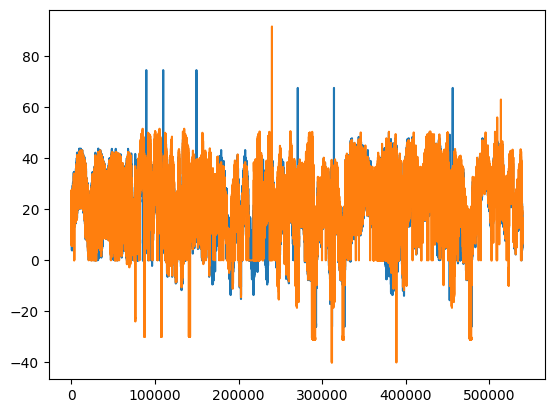

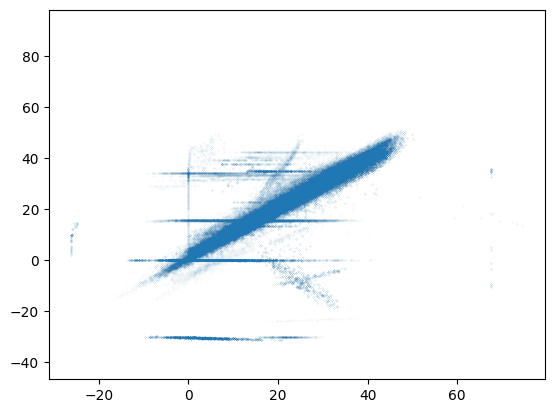

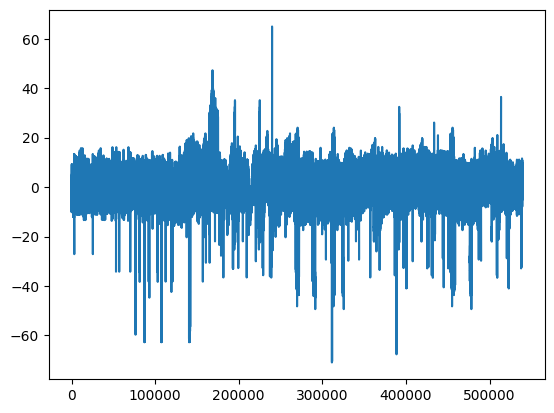

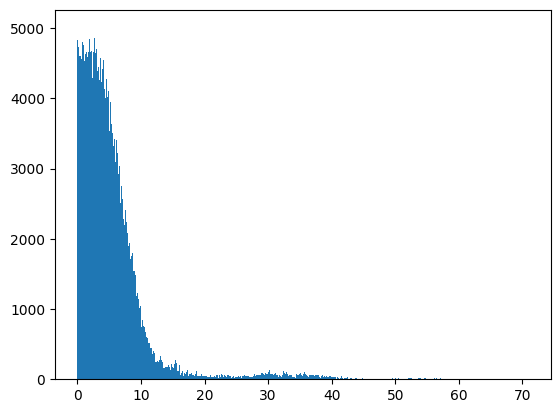

np.float64(0.9994769111606671)

In [112]:
plt.plot(t1)
plt.plot(t2)
plt.show()
plt.scatter(t1, t2, s=0.01, alpha=0.1)
plt.show()
t_diff1 = t1 - t2
plt.plot(t_diff)
plt.show()
plt.hist(abs(t_diff), bins=1000)
plt.show()
np.mean(t_diff)

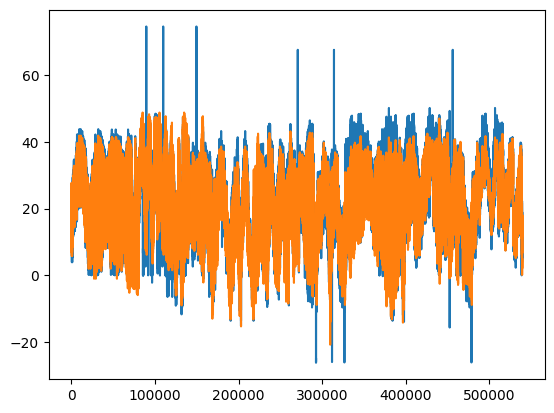

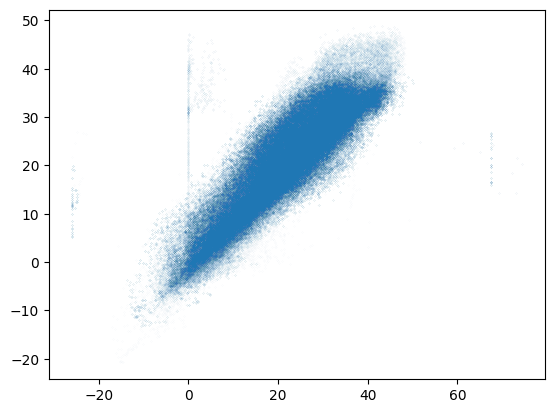

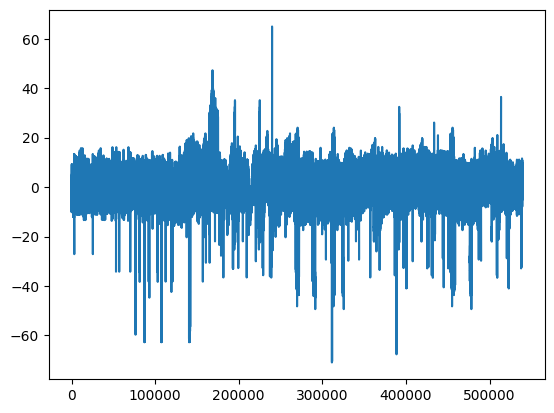

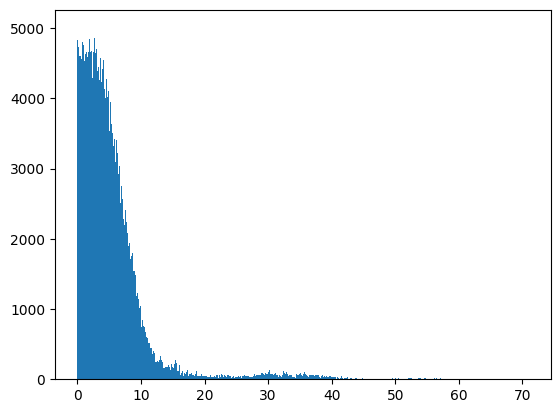

np.float64(0.9994769111606671)

In [113]:
plt.plot(t1)
plt.plot(t3)
plt.show()
plt.scatter(t1, t3, s=0.01, alpha=0.1)
plt.show()
t_diff2 = t1 - t3
plt.plot(t_diff)
plt.show()
plt.hist(abs(t_diff), bins=1000)
plt.show()
np.mean(t_diff)

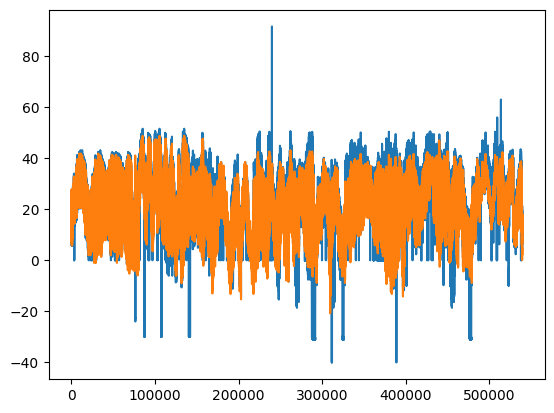

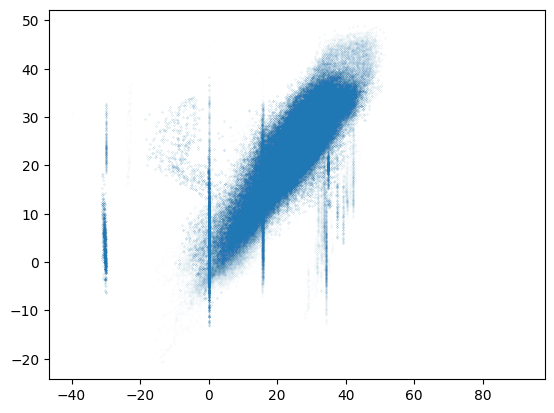

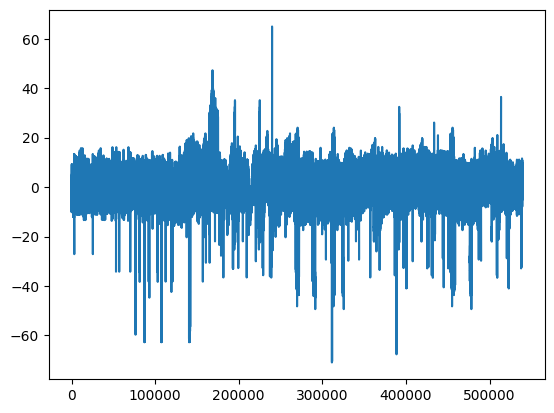

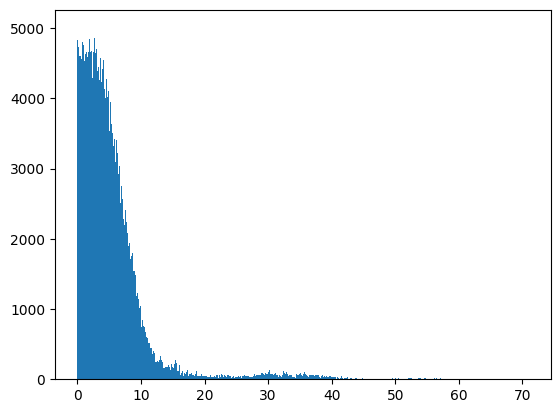

np.float64(0.9994769111606671)

In [114]:
plt.plot(t2)
plt.plot(t3)
plt.show()
plt.scatter(t2, t3, s=0.01, alpha=0.1)
plt.show()
t_diff3 = t2 - t3
plt.plot(t_diff)
plt.show()
plt.hist(abs(t_diff), bins=1000)
plt.show()
np.mean(t_diff)

In [118]:
print("sen - env: ", t_diff1.mean())
print("sen - temp: ", t_diff2.mean())
print("env - temp: ", t_diff3.mean())


sen - env:  -0.32073816592461285
sen - temp:  0.6787387452360545
env - temp:  0.9994769111606671
